In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import networkx as nx
import torch
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
from src.models.staged import STAGED
from src.utils.graph_constructor import GraphConstructor
from src.utils.simulated_data_processing import retrieve_simulated_data

from src.utils.data_factory import create_oscillatory_dynamics_data
from src.utils.visualization import visualize_attention_graph, visualize_graph

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
cell_to_plot = 1  # index of the cell to plot

In [5]:
# data = retrieve_simulated_data(data_dir='../data/raw',sim_file='100_simulation_results.pkl')
# for key, value in data.items():
#     if isinstance(value, (torch.Tensor, np.ndarray)):
#         print(f"{key}: {value.shape}")
#     elif isinstance(value, (list, dict)):
#         print(f"{key}: length {len(value)}")
#     else:
#         print(f"{key}: {value}")

In [6]:
data = create_oscillatory_dynamics_data(
            n_time_points=25,
            n_cells=7,
            n_genes=6,
            dt=0.4,
            noise_level=0.05,
            device='cpu'
        )
for key, value in data.items():
    if isinstance(value, (torch.Tensor, np.ndarray)):
        print(f"{key}: {value.shape}")
    elif isinstance(value, (list, dict)):
        print(f"{key}: length {len(value)}")
    else:
        print(f"{key}: {value}")

gene_expression: torch.Size([25, 7, 6])
cell_positions: torch.Size([25, 7, 2])
genes: length 6
cell_type_assignments: torch.Size([7])
ligand_receptor_pairs: length 2
receptor_gene_pairs: length 4
prior_grns: length 2
n_time_points: 25
n_cells: 7
n_genes: 6
dt: 0.4
time_points: torch.Size([25])


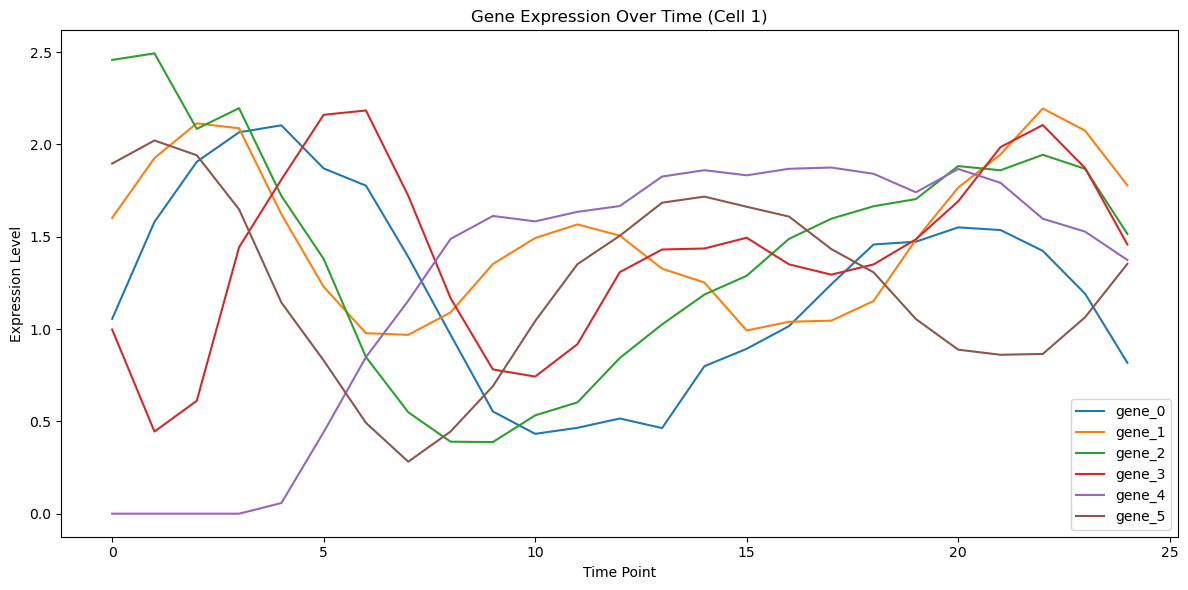

In [7]:
# Plot gene expression for all genes in all cells over time
gene_expression = data['gene_expression']  # shape: (n_time_points, n_cells, n_genes)
n_time_points, n_cells, n_genes = gene_expression.shape

plt.figure(figsize=(12, 6))
for gene_idx in range(n_genes):
    plt.plot(
        range(n_time_points),
        gene_expression[:, cell_to_plot, gene_idx].cpu().numpy(),
        label=f"{data['genes'][gene_idx]}"
    )
plt.xlabel("Time Point")
plt.ylabel("Expression Level")
plt.title(f"Gene Expression Over Time (Cell {cell_to_plot})")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
import pickle

with open('../inference_results/inference_celltype_None_ode_new.pkl', 'rb') as f:
    infered_results = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '../inference_results/inference_celltype_None_ode_new.pkl'

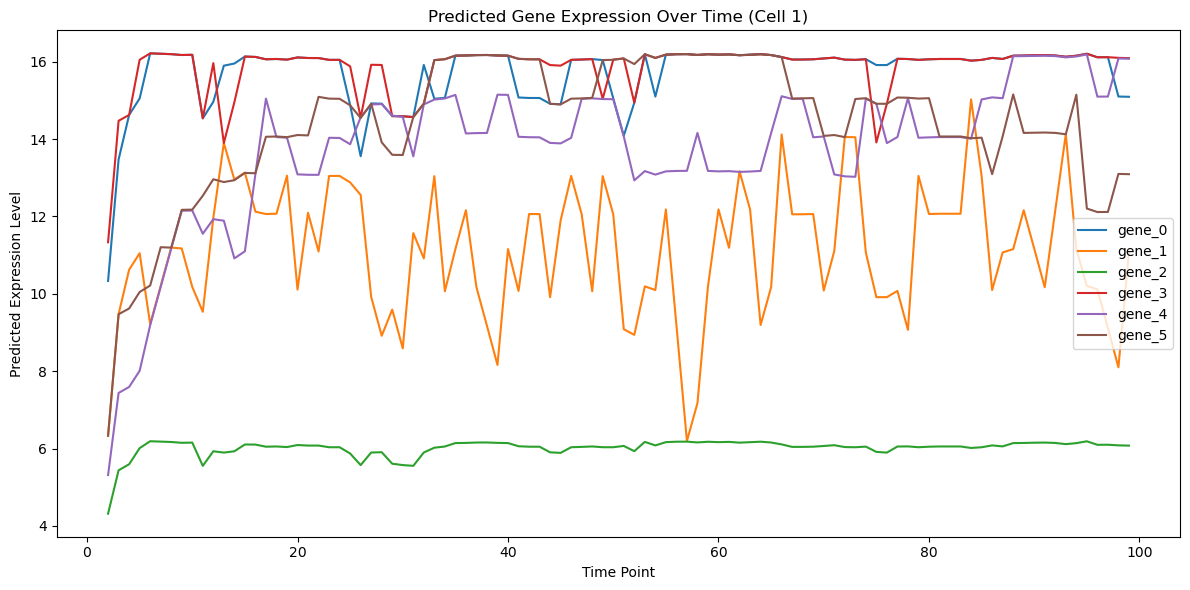

In [ ]:
predictions = infered_results['predictions']  # shape: (n_pred_time_points, n_cells, n_genes)
time_points = infered_results['time_points']
genes = infered_results['genes']

plt.figure(figsize=(12, 6))
for gene_idx, gene_name in enumerate(genes):
    plt.plot(time_points, predictions[:, cell_to_plot, gene_idx], label=gene_name)
plt.xlabel("Time Point")
plt.ylabel("Predicted Expression Level")
plt.title(f"Predicted Gene Expression Over Time (Cell {cell_to_plot})")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os

output_dir = '../inference_results/plots'
os.makedirs(output_dir, exist_ok=True)

for cell_idx in range(n_cells):
    plt.figure(figsize=(12, 6))
    for idx, gene_name in enumerate(genes):
        # True gene expression
        plt.plot(
            range(n_time_points),
            gene_expression[:, cell_idx, idx].cpu().numpy(),
            label=f"True {gene_name}"
        )
        # Predicted gene expression
        plt.plot(
            time_points,
            predictions[:, cell_idx, idx],
            linestyle='--',
            label=f"Predicted {gene_name}"
        )
    plt.xlabel("Time Point")
    plt.ylabel("Expression Level")
    plt.title(f"True vs Predicted Gene Expression Over Time (Cell {cell_idx})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'cell_{cell_idx}_gene_expression.png'))
    plt.close()